### Instructions: 
 - define model parameters, 
 - fit model to data to calibrate velocity scale, 
 - fit data and model to lorentzian, 
 - verify the are consistent

In [2]:
from mossbauer_analysis.ironanalytics_load import read_ironanalytics_data, print_ironanalytics_metadata 
import mossbauer_analysis.utils as u
from mossbauer_analysis.ironanalytics_analyze import fit_and_calibrate
from mossbauer_analysis.mossbauer_theory import CobaltRhodium, CobaltFe, KFeCy, alphaFe, Mossbauer
import os
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def lorentzian(p,x):
    x0, Gamma, A, eta_nr = p
    return eta_nr-A*(Gamma/2)**2 / ((x-x0)**2 + (Gamma/2)**2)


In [ ]:
v = np.linspace(-3,3,1000)    


#SOURCE
sourceFe = CobaltFe ()
sourceFe.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
sourceFe.Gamma_ev = 6.75e-9
sourceFe.update_params()

#ABSORBER Alpha Fe
absorberAlpha = alphaFe()
absorberAlpha.thickness_m = 25e-6
absorberAlpha.abundance = 0.0212
absorberAlpha.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn


absorberAlpha.update_params()


#ABSORBER A1
absorberA1 = alphaFe()
absorberA1.thickness_m = 260e-9
absorberA1.abundance = 0.96
absorberA1.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorberA1.update_params()
#CALCULATIONS
moss_Alpha = Mossbauer(sourceFe, absorberAlpha)
moss_A1 = Mossbauer(sourceFe, absorberA1)

t_Alpha = moss_Alpha.total_transmission_rate(v)
t_A1 = moss_A1.total_transmission_rate(v)



#ABSORBER A2
absorberA2 = alphaFe()
absorberA2.thickness_m = 200e-9
absorberA2.abundance = 0.96
absorberA2.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorberA2.update_params()
#CALCULATIONS
moss_Alpha = Mossbauer(sourceFe, absorberAlpha)
moss_A2 = Mossbauer(sourceFe, absorberA2)   

t_Alpha = moss_Alpha.total_transmission_rate(v)
t_A2 = moss_A2.total_transmission_rate(v)




In [121]:
directory = "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/"
["A00135","A00137","A00138","A00141","A00142"]

data_alphaFe = read_ironanalytics_data(directory, "A00137", offset = -3, plot = False)
data_A1 = read_ironanalytics_data(directory, "A00141", offset = -3, plot = False)
data_A2 = read_ironanalytics_data(directory, "A00142", offset = -3, plot = False)

## AlphaFe

Fit parameters: A=1.105, s=1.372, v0=-0.004, B=0.688
Lorentzian fit to measurement: x0:-0.011, Gamma:0.279, A:0.105, eta_nr:1.001
Lorentzian fit to model:       x0:-0.000, Gamma:0.279, A:0.107, eta_nr:1.001
Note:the linewidth is not fitted!
Minimum theory linewidth (no thickness broadening, just source+absorber): 0.141+0.095 = 0.235 mm/s


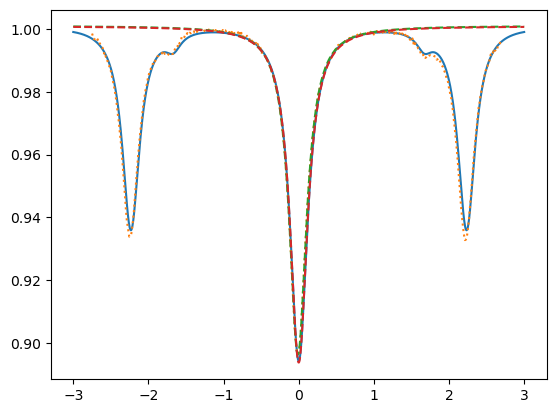

In [157]:
from scipy.interpolate import interp1d


# Model Data and interpolation function
x_model = v
y_model = t_Alpha
model_interp = interp1d( x_model, y_model, kind="cubic",bounds_error=False,fill_value=0.0)

def fit_interpolation(p,x):
    A, s, x0, B = p
    return A * model_interp(s * (x - x0)) + B


# Measured Data
x_meas = data_alphaFe.velocity_list
y_meas = data_alphaFe.data_folded/max(data_alphaFe.data_folded)



#Fit the model to the data
p, dp = u.fit(fit_interpolation, x_meas, y_meas, p0=[1,1.3,0,0.7], fullout=False)
A, s, v0, B = p
print(f"Fit parameters: A={A:.3f}, s={s:.3f}, v0={v0:.3f}, B={B:.3f}")
plt.plot(x_model, A*y_model+B, label='Alpha Fe Absorber')
plt.plot((x_meas+v0)*s, y_meas, label='Alpha Fe Data', linestyle='dotted')


#now fit a lorentzian to see actual linewidth
#select limited vrange
x_calibrated = (x_meas+v0)*s
idx0 = np.argmin(np.abs(x_calibrated - (-1.3)))
idx1 = np.argmin(np.abs(x_calibrated - 1.3))
x_meas_fit = x_calibrated[idx0:idx1]
y_meas_fit = y_meas[idx0:idx1]
p, dp = u.fit(lorentzian, x_meas_fit, y_meas_fit, p0=[0,0.2,0.5,0], fullout=False)
print(f"Lorentzian fit to measurement: x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit', linestyle='--')

#also fit the model linewidth
idx0 = np.argmin(np.abs(x_model - (-1.3)))
idx1 = np.argmin(np.abs(x_model - 1.3))
x_mod_fit = x_model[idx0:idx1]
y_mod_fit = y_model[idx0:idx1]
p, dp = u.fit(lorentzian, x_mod_fit, A*y_mod_fit+B, p0=p, fullout=False)
print(f"Lorentzian fit to model:       x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
print("Note:the linewidth is not fitted!")
plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit Model', linestyle='--')

print(f"Minimum theory linewidth (no thickness broadening, just source+absorber): {sourceFe.Gamma:.3f}+{absorberAlpha.Gamma:.3f} = { sourceFe.Gamma + absorberAlpha.Gamma :.3f} mm/s")

## A1

Fit parameters: A=0.328, s=1.381, v0=-0.003, B=0.675
Lorentzian fit to measurement: x0:-0.007, Gamma:0.255, A:0.066, eta_nr:0.998
Lorentzian fit to model:       x0:0.000, Gamma:0.255, A:0.068, eta_nr:0.998
Note:the linewidth is not fitted!
Minimum theory linewidth (no thickness broadening, just source+absorber): 0.141+0.095 = 0.235 mm/s


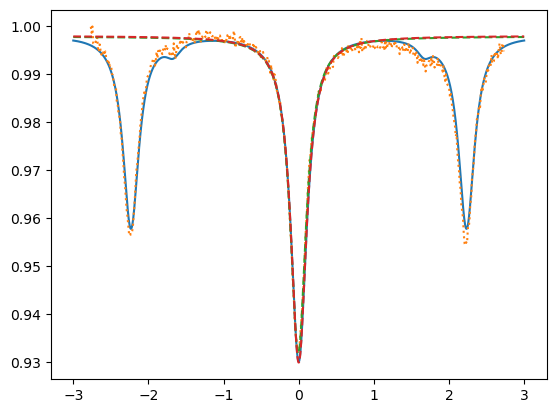

In [168]:
from scipy.interpolate import interp1d


# Model Data and interpolation function
x_model = v
y_model = t_A1
model_interp = interp1d( x_model, y_model, kind="cubic",bounds_error=False,fill_value=0.0)

def fit_interpolation(p,x):
    A, s, x0, B = p
    return A * model_interp(s * (x - x0)) + B


# Measured Data
x_meas = data_A1.velocity_list
y_meas = data_A1.data_folded/max(data_A1.data_folded)


#Fit the model to the data
p, dp = u.fit(fit_interpolation, x_meas, y_meas, p0=[1,1.3,0,0.7], fullout=False)
A, s, v0, B = p
print(f"Fit parameters: A={A:.3f}, s={s:.3f}, v0={v0:.3f}, B={B:.3f}")
plt.plot(x_model, A*y_model+B, label='Alpha Fe Absorber')
plt.plot((x_meas+v0)*s, y_meas, label='Alpha Fe Data', linestyle='dotted')


#now fit a lorentzian to see actual linewidth
#select limited vrange
x_calibrated = (x_meas+v0)*s
idx0 = np.argmin(np.abs(x_calibrated - (-1.3)))
idx1 = np.argmin(np.abs(x_calibrated - 1.3))
x_meas_fit = x_calibrated[idx0:idx1]
y_meas_fit = y_meas[idx0:idx1]
p, dp = u.fit(lorentzian, x_meas_fit, y_meas_fit, p0=[0,0.2,0.5,0], fullout=False)
print(f"Lorentzian fit to measurement: x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit', linestyle='--')

#also fit the model linewidth
idx0 = np.argmin(np.abs(x_model - (-1.3)))
idx1 = np.argmin(np.abs(x_model - 1.3))
x_mod_fit = x_model[idx0:idx1]
y_mod_fit = y_model[idx0:idx1]
p, dp = u.fit(lorentzian, x_mod_fit, A*y_mod_fit+B, p0=p, fullout=False)
print(f"Lorentzian fit to model:       x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
print("Note:the linewidth is not fitted!")
plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit Model', linestyle='--')

print(f"Minimum theory linewidth (no thickness broadening, just source+absorber): {sourceFe.Gamma:.3f}+{absorberAlpha.Gamma:.3f} = { sourceFe.Gamma + absorberAlpha.Gamma :.3f} mm/s")

## A2

Fit parameters: A=0.304, s=1.385, v0=-0.004, B=0.696
Lorentzian fit to measurement: x0:-0.010, Gamma:0.250, A:0.050, eta_nr:0.997
Lorentzian fit to model:       x0:-0.000, Gamma:0.250, A:0.052, eta_nr:0.997
Note:the linewidth is not fitted!
Minimum theory linewidth (no thickness broadening, just source+absorber): 0.141+0.095 = 0.235 mm/s


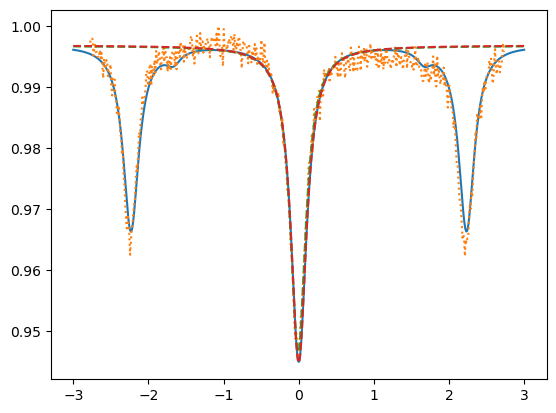

In [169]:
from scipy.interpolate import interp1d


# Model Data and interpolation function
x_model = v
y_model = t_A2
model_interp = interp1d( x_model, y_model, kind="cubic",bounds_error=False,fill_value=0.0)

def fit_interpolation(p,x):
    A, s, x0, B = p
    return A * model_interp(s * (x - x0)) + B


# Measured Data
x_meas = data_A2.velocity_list
y_meas = data_A2.data_folded/max(data_A2.data_folded)


#Fit the model to the data
p, dp = u.fit(fit_interpolation, x_meas, y_meas, p0=[1,1.3,0,0.7], fullout=False)
A, s, v0, B = p
print(f"Fit parameters: A={A:.3f}, s={s:.3f}, v0={v0:.3f}, B={B:.3f}")
plt.plot(x_model, A*y_model+B, label='Alpha Fe Absorber')
plt.plot((x_meas+v0)*s, y_meas, label='Alpha Fe Data', linestyle='dotted')


#now fit a lorentzian to see actual linewidth
#select limited vrange
x_calibrated = (x_meas+v0)*s
idx0 = np.argmin(np.abs(x_calibrated - (-1.3)))
idx1 = np.argmin(np.abs(x_calibrated - 1.3))
x_meas_fit = x_calibrated[idx0:idx1]
y_meas_fit = y_meas[idx0:idx1]
p, dp = u.fit(lorentzian, x_meas_fit, y_meas_fit, p0=[0,0.2,0.5,0], fullout=False)
print(f"Lorentzian fit to measurement: x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit', linestyle='--')

#also fit the model linewidth
idx0 = np.argmin(np.abs(x_model - (-1.3)))
idx1 = np.argmin(np.abs(x_model - 1.3))
x_mod_fit = x_model[idx0:idx1]
y_mod_fit = y_model[idx0:idx1]
p, dp = u.fit(lorentzian, x_mod_fit, A*y_mod_fit+B, p0=p, fullout=False)
print(f"Lorentzian fit to model:       x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
print("Note:the linewidth is not fitted!")
plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit Model', linestyle='--')

print(f"Minimum theory linewidth (no thickness broadening, just source+absorber): {sourceFe.Gamma:.3f}+{absorberAlpha.Gamma:.3f} = { sourceFe.Gamma + absorberAlpha.Gamma :.3f} mm/s")